Nome: Vinícius Barbosa Bassete

RA: 248135 

Curso: Mestrado em Física Aplicada



# Ex02 - Histograma e Extração de Características

Esta atividade tem 2 objetivos principais: 
  - Entender o conceito de histograma e estatísticas da imagem;
  - Explorar diferentes formas de extração de características em histogramas e sua aplicação em um problema de classificação. 

In [1]:
# Importando as bibliotecas que serão utilizadas
from io import BytesIO
import os
import random

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageFile
import requests
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier

## Parte 1 - Histograma

Leia o notebook [Histograma de imagens](https://github.com/lrittner/Computacao-Visual/blob/master/tutoriais/05_Histograma_da_imagem.ipynb) para entender o conceito de histograma e o uso da função *np.histogram*. Tente também entender a função a seguir, que plota o histograma usando gráfico de barras. Essa função será muito útil nos exercícios deste notebook. 

In [2]:
def plota_hist(h,cor,nbins,bin_edges):

    w=255./nbins #está definindo a largura de cada barra do histograma
    bin_centers = bin_edges[1:]-(w/2)
    plt.bar(bin_centers, h, width=w, color=cor)

### Exercício 1.1

Vamos tentar calcular o histograma de imagens coloridas. Para isso, utilize as imagens tiradas durante o dia ou durante a noite, lidas e apresentadas pelo código abaixo. Observe que elas estão na lista `all_imgs`, sendo a primeira metade as imagens de dia, e a segunda as imagens de noite.

Plote os histogramas de cada uma das bandas das imagens usando gráficos de barras (função `plota_hist`). Compare visualmente os histogramas e comente as principais diferenças observadas. Se você tivesse que dizer quais histogramas pertencem a quais classes de imagem (dia ou noite), você seria capaz de acertar? Explique porque.

In [3]:
def read_image_url(url:str) -> np.ndarray: #recebe uma url e carrega a imagem em um np array.
    response = requests.get(url)
    img = Image.open(BytesIO(response.content))
    img = np.array(img)

    return img

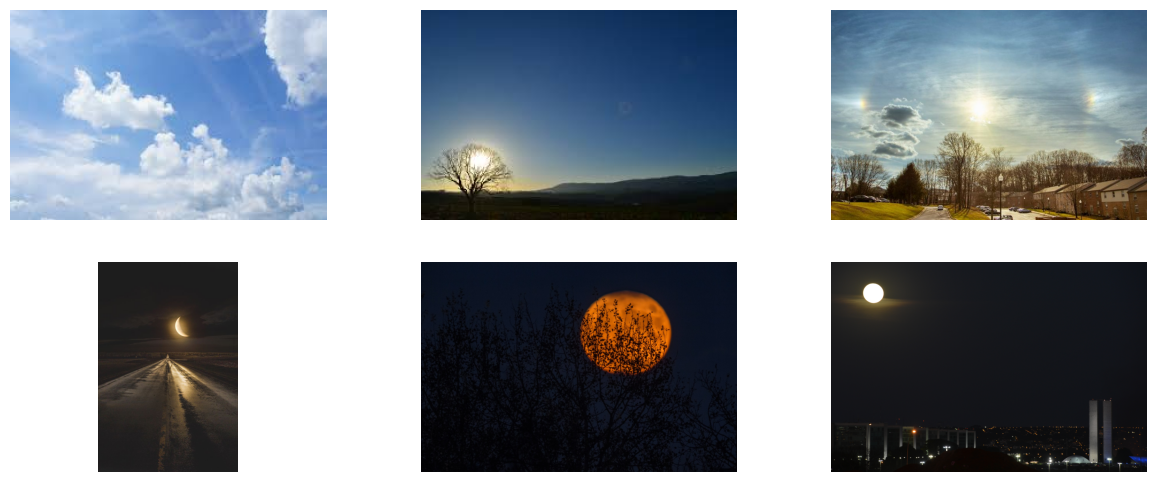

In [4]:
base_path = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/refs/heads/main/imgs/{img_name}.jpg"

fig, axs = plt.subplots(2,3,figsize=(15, 6))

all_imgs = []

index = 0
for daytime in ["dia", "noite"]:
  
  for i in range(3):
    img_name = daytime+"_"+str(i+1)
    img = read_image_url(base_path.format(img_name=img_name))    
    all_imgs.append(img)

    plt.subplot(2,3,1+index)
    plt.axis('off')
    plt.imshow(img)

    index += 1

imagem: 1


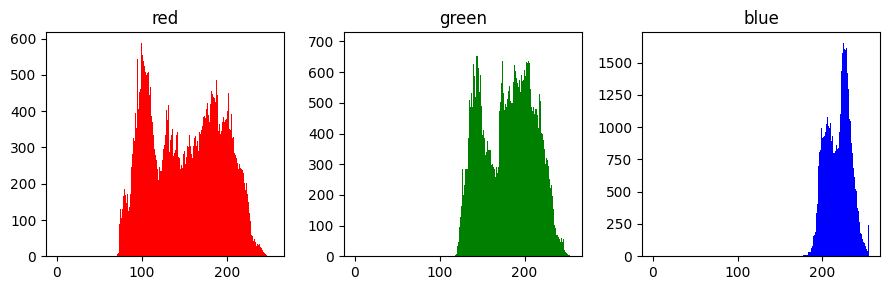

imagem: 2


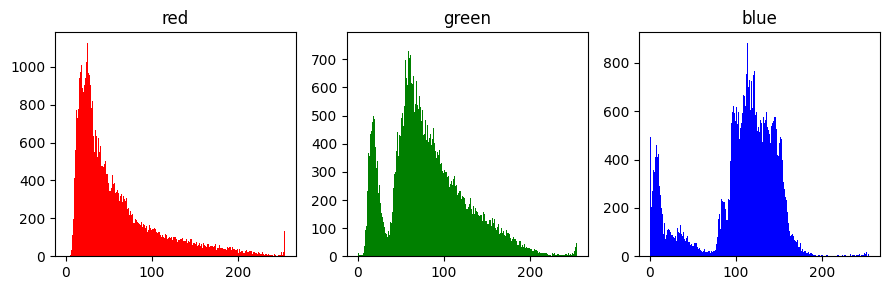

imagem: 3


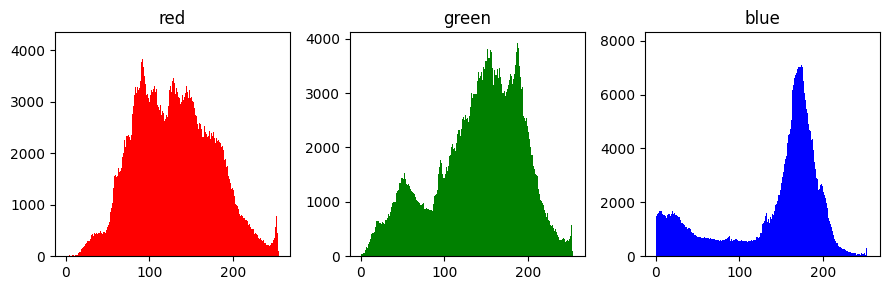

imagem: 4


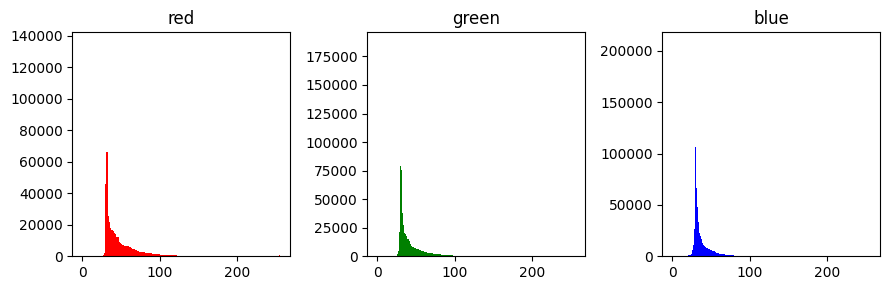

imagem: 5


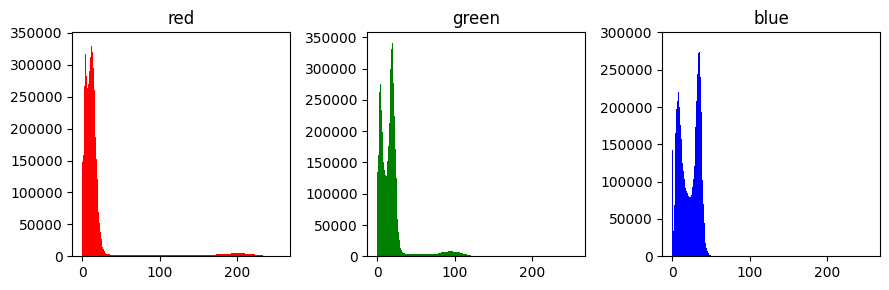

imagem: 6


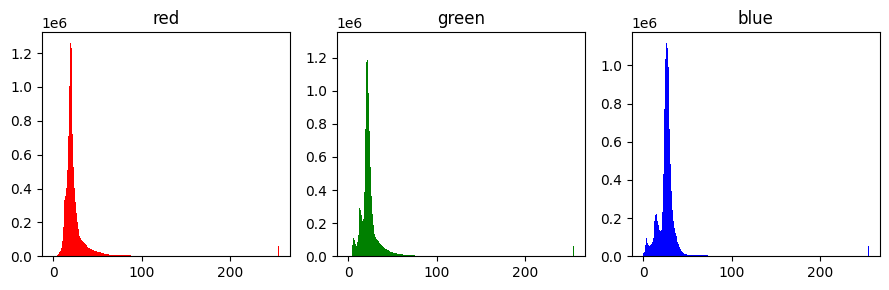

In [5]:
# Ao analisar os histogramas, podemos ver que as imagens diurnas possuem valores de intensidade distribuidos ao longo dos histogramas, com os valores se concentrando em valores acima 100, exceto na segunda imagem, onde, embora seja uma imagem diurna, é mais escura.
# Já as imagens noturnas, apresentam um histograma com valores concentrados na região de intensidade <100, visto que apresentam pixels mais escuros.
# Dadas essas características, uma boa forma de classificar essas imagens seria valor mais frequente, ou pelo valor médio dos pixels da imagem. Nas amostras apresentadas, as imagens diurnas apresentam um valor médio mais alto do que as imagens noturnas.
# 
# -------------------------------------------------------------------------------------------------------------  
cores = ['red','green','blue'] #lista para colorir os histogramas :D
for idx,image in enumerate(all_imgs):
    plt.figure(figsize=(9,3))
    print('imagem:',idx+1)
    for i in range(3):
        plt.subplot(1,3,i+1)
        h,bin_edges = np.histogram(image[:,:,i], 256, (0,255)) #plotando o histograma para todas os 256 possiveis valores dos pixels das imagens. 
        plt.title(cores[i])
        plota_hist(h,cor=cores[i], nbins=255,bin_edges=bin_edges)
    plt.tight_layout()
    plt.show()
    

### Exercício 1.2

Selecione duas imagens coloridas do item anterior (uma de dia e uma de noite) e faça a conversão para níveis de cinza, usando os métodos abaixo:
   - médias das bandas R, G, B;
   - média ponderada das bandas R, G, B: procure qual a poderação mais utilizada;
   - convert(L) da biblioteca PIL (utilize `Image.fromarray(array)` para converter o array para uma imagem do PIL);

Em seguida, calcule o histograma das imagens convertidas para níveis de cinza. Compare os histogramas em níveis de cinza e discuta novamente as diferenças.   

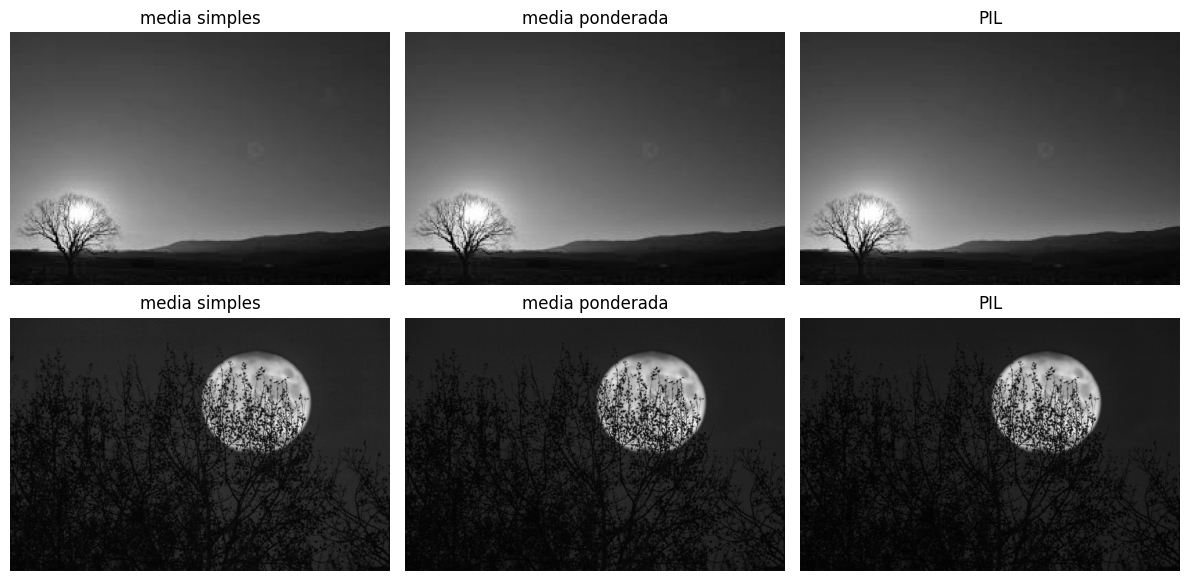

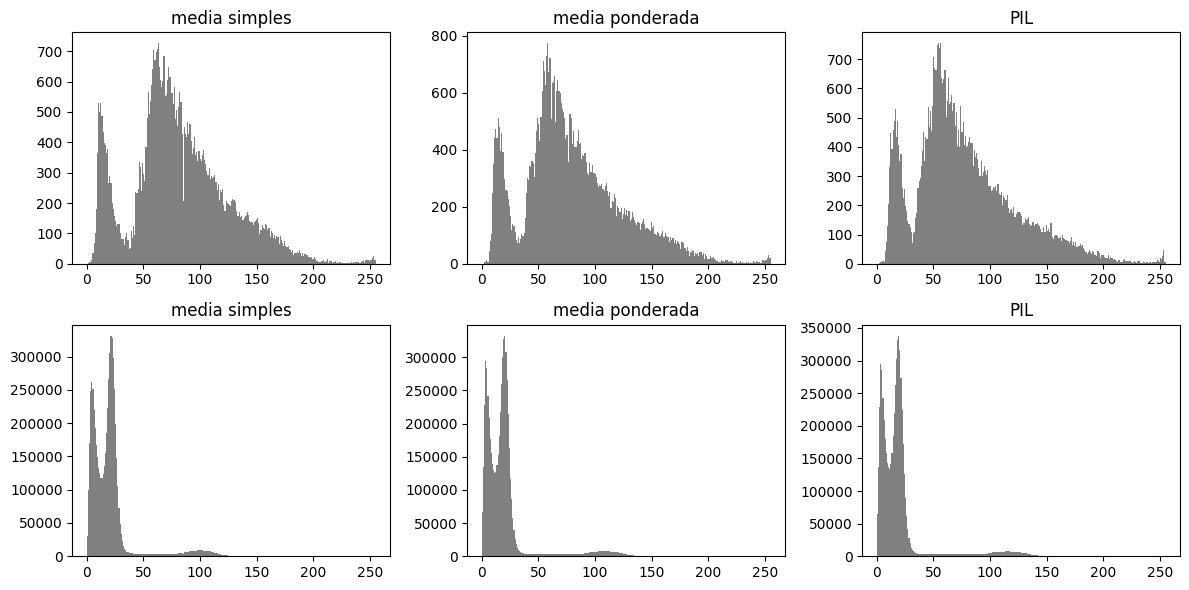

In [6]:
# Para esse exercício, foram selecionadas as imagens 2 e 5. Converteu-se as imagens selecionadas para níveis de cinza utilizando três métodos, aplicando uma média simples entre as bandas RGB, média ponderada com pesos (0.3, 0.5 e 0.2) e utilizando a conversão da biblioteca PIL. Assim, gerou-se os histogramas solicitados.
# Para as imagens selecionadas, em uma análise visual, as imagens utilizando médias ponderadas (o método PIL, segundo a documentação, também realiza uma média ponderada) aparentam ser mais escuras.
# Ao olhar os histogramas, embora mantenham o mesmo formato, podemos ver que há uma leve mudança entre os métodos de conversão, com um pequeno deslocamento dos pixels para valores mais escuros, preenchendo melhor o espectro de cores.
#-------------------------------------------------------------
imagem_dia = all_imgs[1]
imagem_noite = all_imgs[4]

# média das bandas
imagem_dia_cinza_media = np.mean(imagem_dia,axis=2) #executando média no eixo dos canais
imagem_noite_cinza_media = np.mean(imagem_noite,axis=2) #executando média no eixo dos canais

# MÉTODO DA MÉDIA PONDERADA
imagem_noite_cinza_ponderada = 0.3*imagem_noite[:,:,0] + 0.5*imagem_noite[:,:,1] + 0.2*imagem_noite[:,:,2] 
imagem_dia_cinza_ponderada = 0.3*imagem_dia[:,:,0] + 0.5*imagem_dia[:,:,1] + 0.2*imagem_dia[:,:,2] 

#MÉTODO DO PIL
imagem_noite_cinza_PIL = Image.fromarray(imagem_noite).convert('L')
imagem_dia_cinza_PIL = Image.fromarray(imagem_dia).convert('L')

lista_imagens_cinza = [imagem_dia_cinza_media, imagem_dia_cinza_ponderada, imagem_dia_cinza_PIL,
                       imagem_noite_cinza_media, imagem_noite_cinza_ponderada,imagem_noite_cinza_PIL]

labels = ['media simples', 'media ponderada', 'PIL']

plt.figure(figsize=(12,6))
for idx,imagem in enumerate(lista_imagens_cinza):
    plt.subplot(2,3,idx+1)
    plt.title(labels[idx%3])
    plt.imshow(imagem,cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
for idx,imagem in enumerate(lista_imagens_cinza):
    plt.subplot(2,3,idx+1)
    plt.title(labels[idx%3])
    h,bin_edges = np.histogram(imagem, 256, (0,255))
    plota_hist(h,cor='gray',nbins=255,bin_edges=bin_edges)
plt.tight_layout()
plt.show()


## Parte 2 - Extraindo atributos derivados do histograma

Histogramas podem ser utilizados para extrair atributos de imagens. Estes dados são úteis em tarefas de aprendizado de máquina, como a classificação de imagens. 

Dentre os atribitos mais comuns usados para a classificação de imagens, estão: *média*, *variância*, *assimetria* e *curtose*.

A função abaixo calcula, dada uma imagem em níveis de cinza, o histograma e seus atributos. Além dos atributos listados acima, ela também calcula os percentis 1, 10, 50, 90 e 99%.

In [7]:
def histstat(f):
    
    h, bin_edges = np.histogram(f, 256, (0,255))
    hn = 1.0*h/h.sum() # compute the normalized image histogram
    cum_hn = np.cumsum(hn) # compute the cumulative image histogram
    v = np.zeros(9) # number of statistics

    # compute statistics
    n = len(h) # number of gray values
    v[0]  = np.sum((np.arange(n)*hn)) # mean
    v[1]  = np.sum(np.power((np.arange(n)-v[0]),2)*hn) # variance
    v[2]  = np.sum(np.power((np.arange(n)-v[0]),3)*hn)/(np.power(v[1],1.5)) # skewness
    v[3]  = np.sum(np.power((np.arange(n)-v[0]),4)*hn)/(np.power(v[1],2))-3 # kurtosis
    v[4] = np.where(cum_hn >= 0.01)[0][0] # 1% percentile
    v[5] = np.where(cum_hn >= 0.1)[0][0] # 10% percentile
    v[6] = np.where(cum_hn >= 0.5)[0][0] # 50% percentile
    v[7] = np.where(cum_hn >= 0.9)[0][0] # 90% percentile
    v[8] = np.where(cum_hn >= 0.99)[0][0] # 99% percentile

    return v

Se quisermos então extrair os atributos de histograma de uma das imagens tiradas durante o dia, basta fazermos:

In [8]:
f = all_imgs[0]
f_gray = np.uint8(0.3*f[:,:,0]+0.59*f[:,:,1]+0.11*f[:,:,2]) # Conversão para níveis de cinza
hist_features = histstat(f_gray)
for feature in hist_features:
  print(f'{feature:.2f}')

175.75
1035.83
-0.03
-1.11
118.00
132.00
178.00
218.00
237.00


### Exercício 2.1

Extraia agora os atributos de uma das imagens tiradas durante a noite e compare com os atributos da imagem anterior. Eles parecem suficientemente diferentes para distinguir uma da outra?

In [9]:
# Para esse exercício foi utilizada a imagem 5 convertida para níveis de cinza utilizando a conversão da célula acima. Ao compararar as métricas escolhidas, todas os valores obtidos para a imagem noturna são suficientemente distintos da imagem diurna. 
# A imagem diurna apresenta uma intensidade de pixel média e variância muito maior do que a imagem noturna, o que indica uma melhor utilização do espectro de cores (esperado para uma imagem diurna). Já a imagem noturna apresenta uma intensidade de pixel média e variância pequenos, mostrando a concentração em cores escuras (esperado para uma imagem noturna). 
print('Estatísticas da imagem de noite: ')
f = all_imgs[5]
f_gray = np.uint8(0.3*f[:,:,0]+0.59*f[:,:,1]+0.11*f[:,:,2]) # Conversão para níveis de cinza
hist_features = histstat(f_gray)
for feature in hist_features:
  print(f'{feature:.2f}')

#labels: média, variancia, skewness, kurtosis, 1%, 10%, 50%, 90% e 99%

Estatísticas da imagem de noite: 
25.47
523.00
6.96
60.49
7.00
13.00
21.00
36.00
120.00


## Parte 3 - Classificação de imagens utilizando atributos derivados do histograma

### O classificador dos K-vizinhos mais próximos (KNN ou K-Nearest Neighbors) 

[KNN (K-Nearest Neighbors)](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) é um algoritmo de classificação que usa uma abordagem baseada em instâncias, ou seja, ele classifica uma nova amostra com base nas amostras mais próximas (vizinhas) a ela. O KNN se baseia na suposição de que amostras próximas no espaço de atributos estão mais propensas a pertencer à mesma classe.

Para classificar imagens usando o algoritmo KNN, primeiro o conjunto de dados de treinamento é utilizado para construir uma representação dos dados que permita a busca dos vizinhos mais próximos.

Em seguida, para classificar uma nova amostra, o algoritmo encontra as K amostras mais próximas na representação construída, em que K é um parâmetro definido pelo usuário.

Por fim, a classe da nova amostra é determinada pela classe mais comum entre os vizinhos encontrados.



### Exemplo de uso do KNN: 

Um conjunto de dados de duas classes é gerado aleatoriamente e, em seguida, o modelo KNN é treinado com k=5 vizinhos próximos. Note que a função **KNeighborsClassifier()** foi importada da biblioteca **sklearn.neighbors** e foi utilizada para criar o modelo KNN. A função *fit()* foi utilizada para treinar o modelo

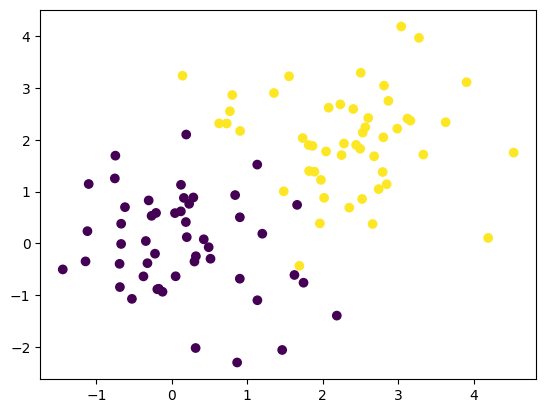

In [10]:
# Geração de dados aleatórios
np.random.seed(1)
X1 = np.random.randn(50, 2)  # 50 amostras da classe 1
X2 = np.random.randn(50, 2) + 2  # 50 amostras da classe 2
X = np.concatenate((X1, X2))
Y = np.concatenate((np.zeros(50), np.ones(50))) # rótulos das classes (0 e 1)

# Visualizando as amostras (coloridas por classe)
plt.scatter(X[:,0],X[:,1],c=Y)
plt.show()

# Criando o modelo KNN
model = KNeighborsClassifier(n_neighbors=5)

# Treinando o modelo
model.fit(X, Y);

Em seguida, novas amostras aleatórias foram criadas para teste e o modelo foi utilizado para classificá-las. 

A função *predict()* é utilizada para classificar as novas amostras.



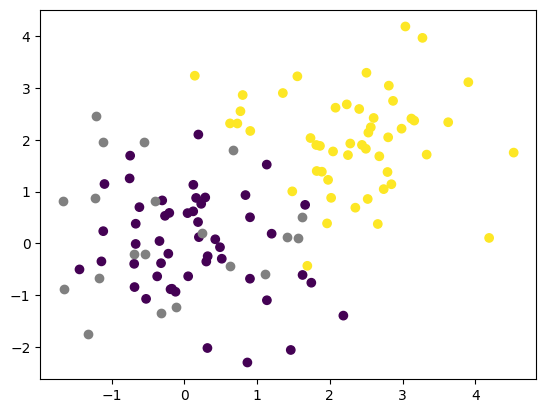

In [11]:
# Criando novas amostras aleatórias para teste
X_test = np.random.randn(20, 2)

#  Visualizando o conjunto de teste
plt.scatter(X[:,0],X[:,1],c=Y)
plt.scatter(X_test[:,0],X_test[:,1],c='gray')
plt.show()

# Classificando as amostras
Y_test_pred = model.predict(X_test)

Para avaliar a qualidade de um classificador, normalmente se utiliza as seguintes métricas:

- [Acurácia (accuracy_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html): mede a proporção de amostras classificadas corretamente pelo modelo.
- [Precisão (precision_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html): mede a proporção de amostras classificadas como positivas (1) que são realmente positivas.
- [Recall (recall_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html): mede a proporção de amostras positivas (1) que são corretamente identificadas pelo modelo.
- [F1-Score (f1_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html): média harmônica entre precisão e recall.

Note que estas não são as únicas métricas utilizadas para avaliar um classificador. A escolha das métricas depende do contexto e dos objetivos da classificação. Na medicina, por exemplo, costuma-se utilizar a sensibilidade (ou recall) e a especificidade (mede a proporção de amostras negativas (0) que são corretamente identificadas pelo modelo). Dessa forma, pode-se determinar em que medida o classificador/exame é sensível à condição em questão (detecta corretamente as amostras positivas) e específico para detectar apenas ela (detecta corretamente as amostras negativas).

**Atenção**: para avaliar o modelo, as métricas foram calculadas em relação às amostras de treinamento, o que **não** é o ideal em um cenário real de classificação. No entanto, para fins didáticos, pode-se utilizar essas métricas para avaliar o desempenho do modelo.

In [12]:
# Avaliando o modelo (as funções foram importadas previamente da biblioteca sklearn.metrics)
acc = accuracy_score(Y, model.predict(X))
prec = precision_score(Y, model.predict(X))
rec = recall_score(Y, model.predict(X))
f1 = f1_score(Y, model.predict(X))

# Imprimindo as métricas
print('Acurácia: %.2f' % acc)
print('Precisão: %.2f' % prec)
print('Recall: %.2f' % rec)
print('F1-Score: %.2f' % f1)

Acurácia: 0.96
Precisão: 0.94
Recall: 0.98
F1-Score: 0.96


Para fazer uma avaliação qualitativa do classificador, podemos plotar os resultados da classificação utilizando a função [scatter()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) do matplotlib. As amostras de treinamento são plotadas com pontos circulares, enquanto as amostras de teste são plotadas com pontos cruzados.


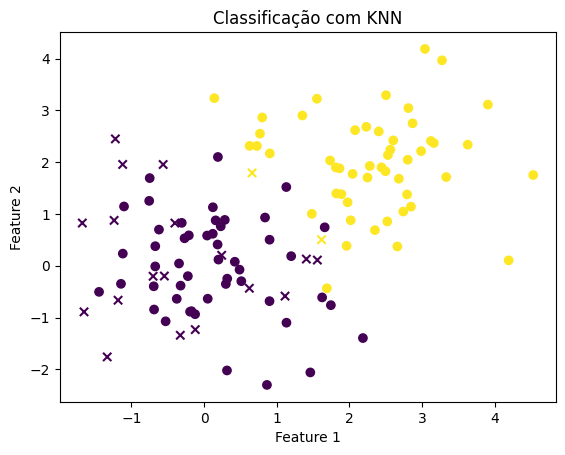

In [13]:
# Plotando os resultados
plt.scatter(X[:, 0], X[:, 1], c=Y)
plt.scatter(X_test[:, 0], X_test[:, 1], marker='x', c=Y_test_pred)
plt.title('Classificação com KNN')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

### Exercício 3.1

Vamos agora usar o mesmo classificador KNN para classificar imagens, utilizando um dataset de imagens dermatoscópicas de lesões de pele comuns.

**Dataset**

O dataset consiste em 500 imagens de lesões de pele, obtidas ao longo de 20 anos em dois hospitais diferentes. Como as imagens foram obtidas e armazenadas de diferentes formas ao longo do tempo (armazenadas em arquivos PowerPoint, por exemplo), elas passaram por um processo de seleção, organização e padronização para compor o dataset. Assim, as imagens foram cortadas em torno das lesões de modo a deixá-las centralizadas e, em alguns casos, tiveram seus histogramas corrigidos manualmente para melhorar o contraste visual e a reprodução de cores.

As imagens estão divididas em dois tipos de lesão de pele:
- 250 casos de carcinoma basocelular (label 0) - um tipo de câncer de pele que começa nas células basais, raramente apresenta metástase, mas cresce de forma destrutiva se não tratado;
- 250 casos de melanoma (label 1) - o tipo mais grave de câncer de pele, que começa nas células produtoras de melanina, é quase sempre curável em estágios iniciais, mas tende a apresentar metástase com o tempo.

**Classificação**

O dataset está separado em um conjunto de treino com 400 imagens (200 de cada classe) e um conjunto de teste com 100 imagens (50 de cada classe).

Neste caso, ao invés de utilizar dados aleatórios para treinamento e teste, vamos extrair os atributos dos histogramas dos conjuntos de imagens. Os atributos serão utilizadas como dados de entrada do modelo. As imagens devem ser classificadas em 0 ou 1, representando os dois tipos de lesões presentes no dataset (carcinoma ou melanoma, respectivamente).

O código abaixo cria os conjuntos de treino e teste (imagens e labels) utilizando as imagens disponíveis no dataset.

In [14]:
try:
    from medmnist import DermaMNIST
except:
    !pip install medmnist
    from medmnist import DermaMNIST


In [15]:
train_dataset = DermaMNIST(
    split="train",
    download=True 
)

test_dataset = DermaMNIST(
    split="test",
    download=True
)

#1 = carcinoma -> 0
#4 = melanoma -> 1

In [16]:
images_train = []
labels_train = []
images_test = []
labels_test = []

datasets = {"train":train_dataset, "test":test_dataset}
img_count = {"train":200, "test":50}
images : dict[str, list[np.ndarray]] = {}
labels : dict[str, list[int]] = {}

for split in datasets:
    dataset = datasets[split]
    images[split] = []
    labels[split] = []
    
    counter = {0:0, 1:0}

    for data in dataset:
        img = data[0]
        label = data[1].item()
        if label == 1:
            label = 0
        elif label == 4:
            label = 1
        else:
            continue

        if counter[label] >= img_count[split]:
            continue

        images[split].append(np.array(img))
        labels[split].append(label)

        counter[label] += 1



images_train = images["train"]
labels_train = labels["train"]
images_test = images["test"]
labels_test = labels["test"]


print(f'labels_train: \n{labels_train}')
print('Número de imagens de treino:', len(labels_train))

print(f'labels_test: \n{labels_test}')
print('Número de imagens de teste:', len(labels_test))

labels_train: 
[1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

Agora, vamos visualizar algumas imagens do dataset. O código abaixo seleciona e plota quatro imagens aleatórias de cada classe do conjunto de treino. Tente executá-lo algumas vezes e comparar as duas classes visualmente.

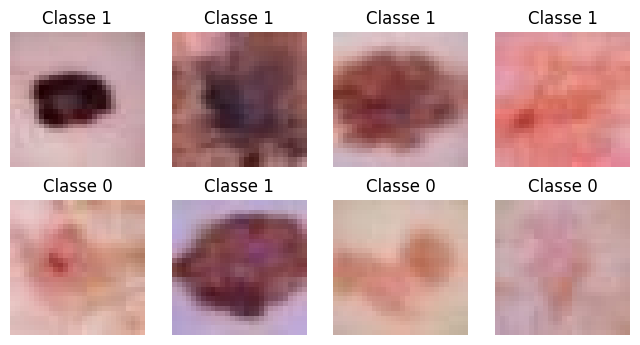

In [17]:
images_train[random.randint(0,199)]
images_train[random.randint(200,399)]

n_imgs = 4
fig, axs = plt.subplots(2,n_imgs,figsize=(8, 4))

for n in range(n_imgs):
  plt.subplot(2,n_imgs,n+1)
  plt.axis('off')
  tmp = random.randint(0,199)
  plt.imshow(images_train[tmp])
  plt.title(f'Classe {labels_train[tmp]}')

  plt.subplot(2,n_imgs,n+n_imgs+1)
  plt.axis('off')
  tmp = random.randint(200,399)
  plt.imshow(images_train[tmp])
  plt.title(f'Classe {labels_train[tmp]}')

**a)** Crie uma função que receba um conjunto de imagens RGB, transforme as imagens em *grayscale*, e extraia os atributos do histograma de cada imagem. A função deve retornar os atributos dos histogramas concatenados em um vetor de atributos. Utilize a função **"histstat"** dada nesse notebook para extração de atributos.

Utilize os conjuntos de dados criados anteriormente para obter os vetores de atributos das amostras de treino e teste (train_features e test_features). 

**Atenção!** Para o conjunto de treino você deve obter uma matriz 400 x 9, onde cada linha corresponde a uma amostra (imagem) e cada coluna correponde a um atributo do histograma. Da mesma forma, para o conjunto de teste você deve obter uma matriz 100 x 9. 

In [18]:
# A função recebe uma lista de imagens e iterativamente adiciona as estatísticas em uma nova lista que é convertida em um array. Crio as variáveis stats_train e stats_tests para armazenar as estátisticas calculadas para treino e teste do modelo.
def FuncaoQueRecebeConjuntoDeImagensRGB(images):
    all_stats = []
    for image in images:
        image = np.array(Image.fromarray(image).convert('L'))
        all_stats.append(histstat(image))
    return np.array(all_stats)


stats_train = FuncaoQueRecebeConjuntoDeImagensRGB(images_train)
print('shape do treino:',stats_train.shape)
stats_test = FuncaoQueRecebeConjuntoDeImagensRGB(images_test)
print('shape do teste:',stats_test.shape)


shape do treino: (400, 9)
shape do teste: (100, 9)


**b)** Treine um modelo kNN utilizando o conjunto de dados de treino criado (train_features). Você precisará escolher um valor de k. Valide o modelo utilizando o conjunto de dados de teste (test_features). Calcule as métricas de avaliação do classificador para ambos os conjuntos de dados (primeiro para treino, depois para teste): acurácia, precisão, revocação e F1-score. Imprima a [Matriz de Confusão](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html).


Métricas para k=6
Acurácia: 0.83
Precisão: 0.82
Recall: 0.84
F1-Score: 0.83
Matriz de confusão:
 [[41  9]
 [ 8 42]]


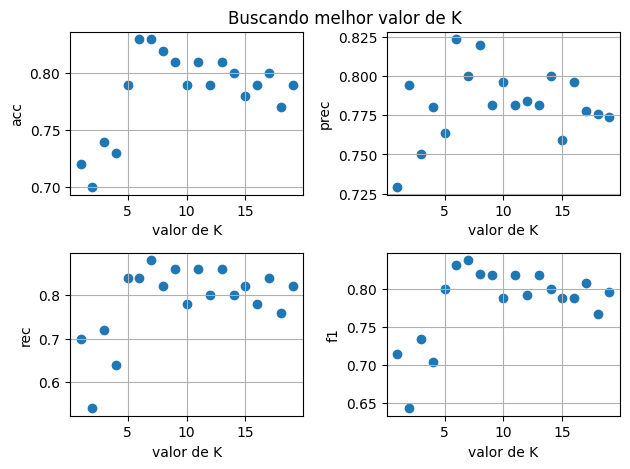

In [19]:
# Seu código aqui
from sklearn.metrics import confusion_matrix
acc,prec,rec,f1 = [],[],[],[]
metric_labels = ['acc','prec','rec','f1']
labels_train = np.array(labels_train) #converte as labels para np.array

for k in range(1,20): # testando varios valores de K para decidir o melhor.
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(stats_train, labels_train); #realiza o treinamento no conjunto de treino
    acc.append(accuracy_score(labels_test, model.predict(stats_test))) #calcula as métricas no conjunto de teste
    prec.append(precision_score(labels_test, model.predict(stats_test)))
    rec.append(recall_score(labels_test, model.predict(stats_test)))
    f1.append(f1_score(labels_test, model.predict(stats_test)))

plt.title('Buscando melhor valor de K')
plt.axis('off')
for idx,graph in enumerate([acc,prec,rec,f1]):
    axis = [i for i in range(1,20)]
    plt.subplot(2,2,idx+1)
    plt.scatter(axis,graph)
    plt.xlabel('valor de K')
    plt.ylabel(metric_labels[idx])
    plt.grid()
    plt.tight_layout()

model = KNeighborsClassifier(n_neighbors=6) #o melhor K no treino foi 6
model.fit(stats_train, labels_train);
# Imprimindo as métricas
print('Métricas para k=6')
print('Acurácia: %.2f' % accuracy_score(labels_test, model.predict(stats_test)))
print('Precisão: %.2f' % precision_score(labels_test, model.predict(stats_test)))
print('Recall: %.2f' % recall_score(labels_test, model.predict(stats_test)))
print('F1-Score: %.2f' % f1_score(labels_test, model.predict(stats_test)))

predicts = model.predict(stats_test)
matriz_de_confusao = confusion_matrix(labels_test,predicts)
print('Matriz de confusão:\n',matriz_de_confusao)

**c)** Tente plotar os resultados da classificação usando os atributos 2 a 2 como eixos (por exemplo, os valores de variância no eixo y e os valores de média no eixo x). Utilize a função [scatter()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) do matplotlib, já demonstrada no início da Parte 3 deste notebook. As amostras de treinamento devem ser plotadas com pontos circulares, enquanto as amostras de teste devem ser plotadas com pontos cruzados. Comente os resultados obtidos.

<Figure size 640x480 with 0 Axes>

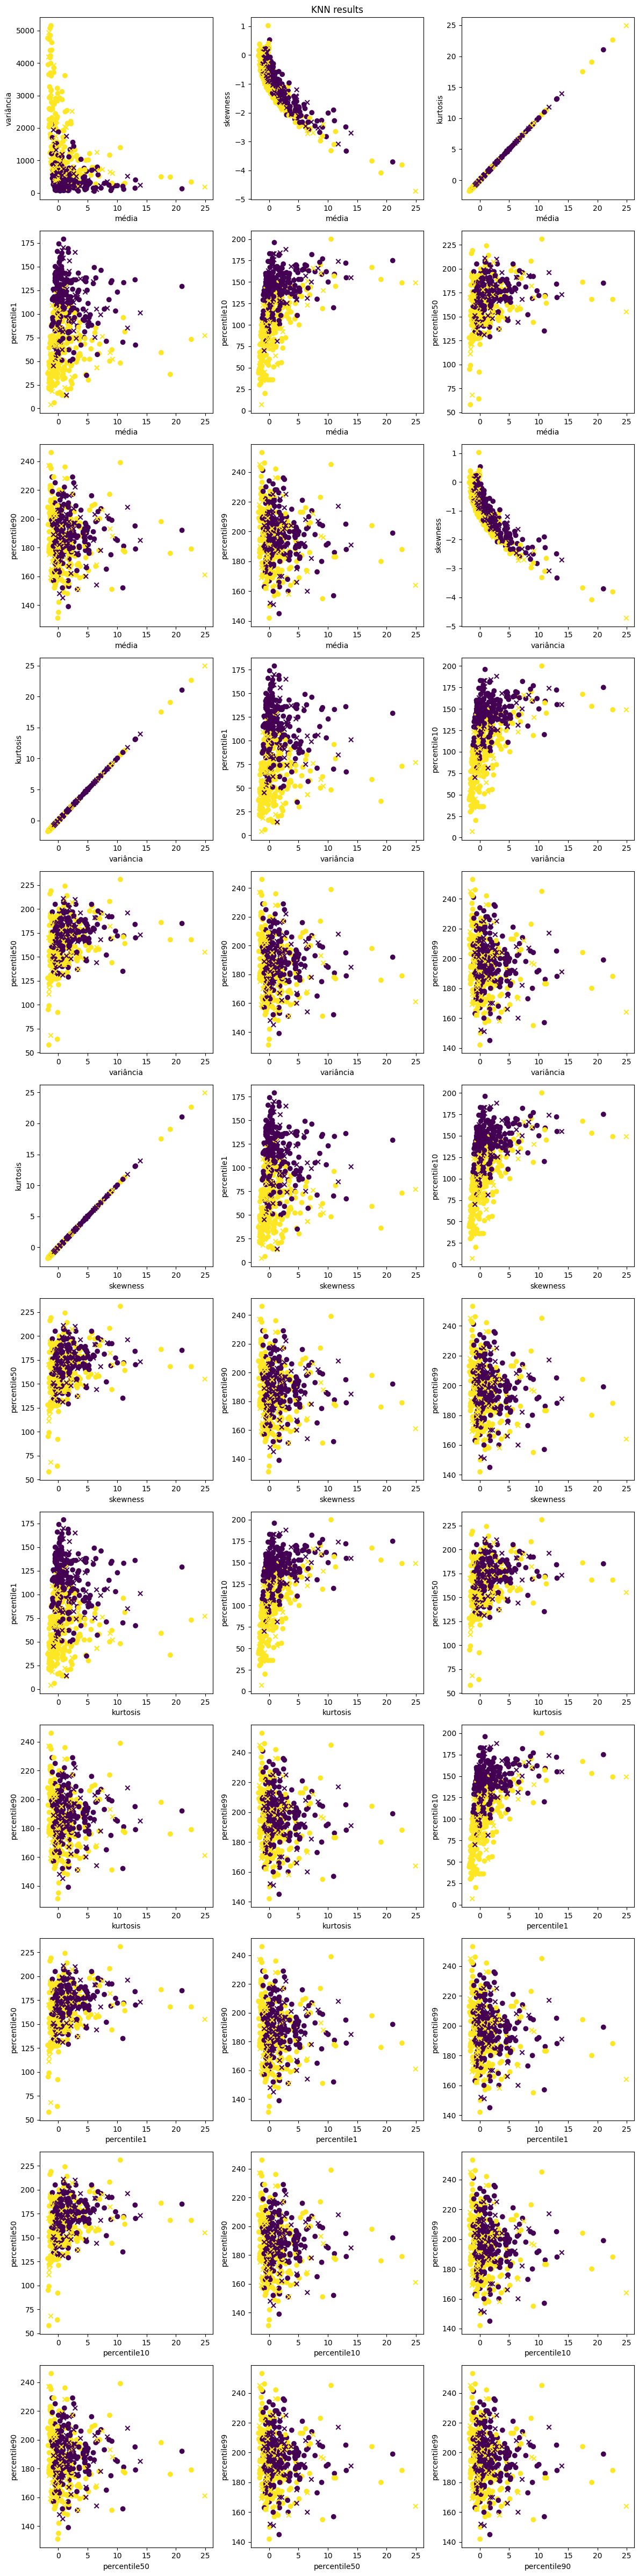

In [20]:
# Observando os gráficos gerados, nota-se que é difícil encontrar uma separação clara das categorias nos planos 2D, entretanto, como o modelo KNN tem uma acertividade alta, a análise multidimensional consegue entregar uma boa separação. 

metricas = ['média','variância','skewness','kurtosis','percentile1','percentile10','percentile50','percentile90','percentile99']
c = 1
plt.clf()
plt.figure(figsize=(12,48))
plt.title('KNN results')
plt.axis('off')
for idx1, metrica1 in enumerate(metricas):
    for metrica2 in metricas[idx1+1:]:
        aux = metricas.index(metrica2)
        plt.subplot(12,3,c)
        plt.scatter(stats_train[:, idx], stats_train[:, aux],c=labels_train)
        plt.scatter(stats_test[:, idx], stats_test[:, aux], marker='x',c=labels_test)
        plt.xlabel(metrica1)
        plt.ylabel(metrica2)
        c+=1
plt.tight_layout()
plt.show()



**d)** Comente os resultados obtidos: Você está satisfeito com o resultado? O que você pode inferir do seu classificador ao observar as métricas obtidas? Qual o erro mais frequente? Quais modificações poderiam ser feitas para tentar obter melhores resultados?

Resposta: O modelo treinado com K = 6 apresentou acurácia de 83%, precisão de 82% e recall de 84%, ou seja, dentre todos os casos acertou 83%, dentre os casos positivos para melanoma acertou 82% e entre os classificados como melanoma acertou 84%. Em geral, o classificador funciona bem, embora o número de falsos negativos (9) não me agrada. Para melhorar os resultados, poderiamos tentar reduzir a dimensionalidade do problema e aplicar algum processamento nas imagens antes de inseri-las no modelo.

### Exercício 3.2

Tente melhorar os resultados de classificação. Algumas sugestões:

- Redimensione as imagens para um tamanho menor **(14, 14)**, isso pode deixar os atributos menos suceptíveis a ruídos e detalhes, focando a classificação em características mais gerais;
- Altere o valor de vizinhos k;
- Em problemas de classificação, especialmente quando temos poucas amostras e muitos atributos, temos o "mal da dimensionalidade". A seleção de atributos pode ser utilizada para contornar esse problema e remover atributos reduntantes (correlacionados) ou irrelevantes. Você pode escolher atributos aleatoriamente, fazer uma análise estatística dos atributos correlacionados, ou ainda fazer uma análise visual. Pode também usar técnicas específicas de seleção de atributos ([feature selection](https://scikit-learn.org/stable/modules/feature_selection.html#feature-selection)).

shape do treino: (400, 9)
shape do teste: (100, 9)


<Figure size 640x480 with 0 Axes>

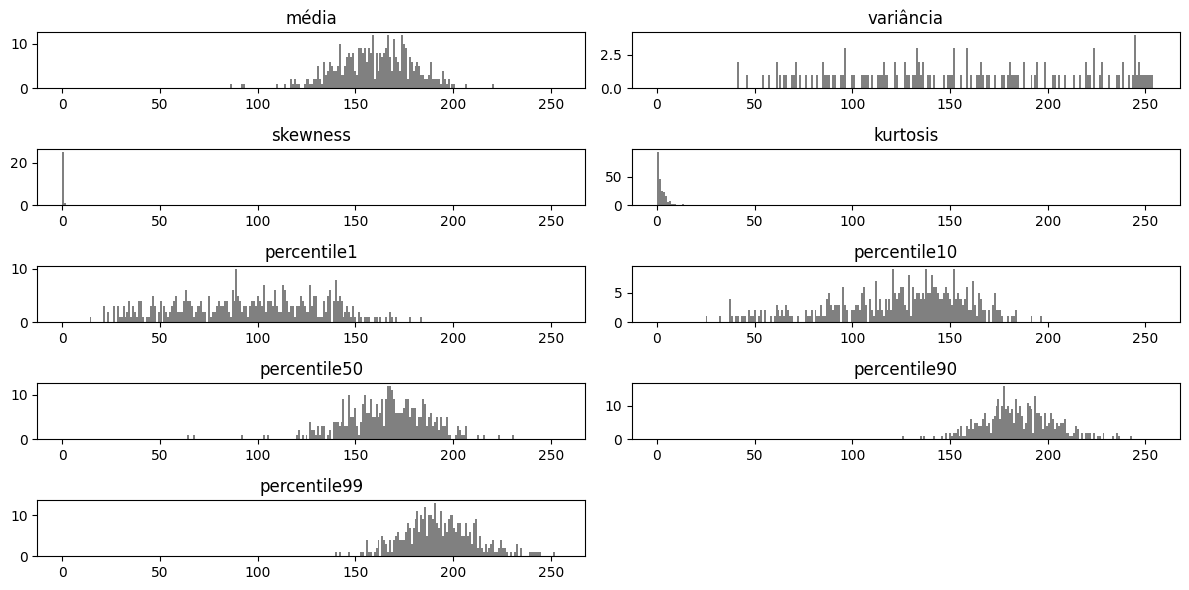

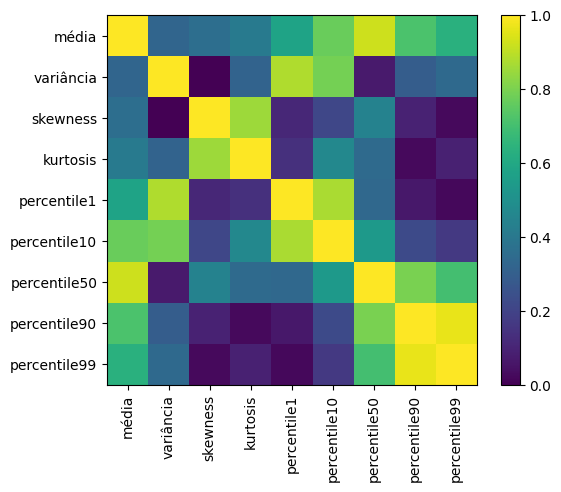

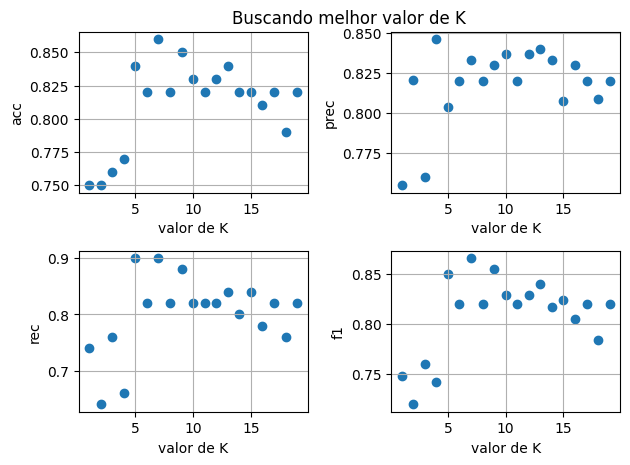

Métricas para k=7
Acurácia: 0.86
Precisão: 0.83
Recall: 0.90
F1-Score: 0.87
Matriz de confusão:
 [[41  9]
 [ 5 45]]


In [ ]:
# Para tentar melhorar o resultado da classificação, realizei o redimensionamento proposto para 14x14, após isso, utilizei os histogramas e o resultado da correlação de Spearman para excluir variáveis visando diminuir a dimensionalidade do problema. Após isso, treinei varios modelos iterando o valor de K (1 até 20). O melhor K encontrado foi K = 7, embora a relaçao TN/FP tenha ficado constante, reduziu-se a relaçao FN/TP, reduzindo o número de imagens classificadas erroneamente como cancerígenas. 

# REDUZINDO O TAMANHO DA IMAGEM
#---------------------------------------------------------------------
def FuncaoQueRecebeConjuntoDeImagensRGB2(images): #função que gerará as estatísticas para a imagem redimensionada.
    all_stats = []
    for image in images:
        image = np.array(Image.fromarray(image).convert('L').resize((14,14),resample=Image.BILINEAR)) # reduzindo o tamanho da imagem de 28x28 para 14x14 via interpolação bilinear
        all_stats.append(histstat(image))
    return np.array(all_stats)

stats_train = FuncaoQueRecebeConjuntoDeImagensRGB2(images_train)
print('shape do treino:',stats_train.shape)
stats_test = FuncaoQueRecebeConjuntoDeImagensRGB2(images_test)
print('shape do teste:',stats_test.shape)
#--------------------------------------------------------------------

# AVALIANDO OS HISTOGRAMAS DE CADA FEATURE NAS DUAS CLASSES
#--------------------------------------------------------------------
plt.clf()
plt.figure(figsize=(12,6))
for idx, feature in enumerate(metricas):
    plt.subplot(5,2,idx+1)
    plt.title(feature)
    h,bin_edges = np.histogram(stats_train[:,idx], 256, (0,255))
    plota_hist(h,cor='gray',nbins=255,bin_edges=bin_edges)
plt.tight_layout()
plt.show()
#--------------------------------------------------------------------

from scipy.stats import spearmanr

corr, _ = spearmanr(stats_train)
plt.imshow(abs(corr), vmin=0, vmax=1)
plt.xticks(range(len(metricas)), metricas, rotation=90)
plt.yticks(range(len(metricas)), metricas)
plt.colorbar()
plt.show()


# REAVALIANDO O VALOR DE K
#--------------------------------------------------------------------
acc,prec,rec,f1 = [],[],[],[]

stats_train_reduzido = stats_train[:,[0,1,3,5,7]] # excluindo kurtosis por baixa variancia, as variaveis percentile1, percentile50 e percentile99 foram excluidas devido a correlação com outras variáveis.
stats_test_reduzido = stats_test[:,[0,1,3,5,7]]                     

for k in range(1,20): # testando varios valores de K para decidir o melhor.                                                             
    model = KNeighborsClassifier(n_neighbors=k)
    
    model.fit(stats_train_reduzido, labels_train); #realiza o treinamento no conjunto de treino
    acc.append(accuracy_score(labels_test, model.predict(stats_test_reduzido))) #calcula as métricas no conjunto de teste
    prec.append(precision_score(labels_test, model.predict(stats_test_reduzido)))
    rec.append(recall_score(labels_test, model.predict(stats_test_reduzido)))
    f1.append(f1_score(labels_test, model.predict(stats_test_reduzido)))

plt.title('Buscando melhor valor de K')
plt.axis('off')
for idx,graph in enumerate([acc,prec,rec,f1]):
    axis = [i for i in range(1,20)]
    plt.subplot(2,2,idx+1)
    plt.scatter(axis,graph)
    plt.xlabel('valor de K')
    plt.ylabel(metric_labels[idx])
    plt.grid()
    plt.tight_layout()
plt.show()
# -------------------------------------------------------------------

# TREINANDO PARA O MELHOR K (K=7)
model = KNeighborsClassifier(n_neighbors=7) #o melhor K no treino foi 7
model.fit(stats_train_reduzido, labels_train);
# Imprimindo as métricas
print('Métricas para k=7')
print('Acurácia: %.2f' % accuracy_score(labels_test, model.predict(stats_test_reduzido)))
print('Precisão: %.2f' % precision_score(labels_test, model.predict(stats_test_reduzido)))
print('Recall: %.2f' % recall_score(labels_test, model.predict(stats_test_reduzido)))
print('F1-Score: %.2f' % f1_score(labels_test, model.predict(stats_test_reduzido)))

predicts = model.predict(stats_test_reduzido)
matriz_de_confusao = confusion_matrix(labels_test,predicts)
print('Matriz de confusão:\n',matriz_de_confusao)

## Parte 4 - Utilizando atributos de histograma de imagens coloridas (opicional para EA979)

Note que, ao realizar a transformação das imagens coloridas para imagens em escala de cinza na Parte 3 deste notebook, estamos desconsiderando características e informações das imagens com potencial para ajudar no processo de classificação.

### Exercício 4.1

Repita o processo de classificação do dataset de imagens dermatoscópicas, mas desta vez utilizando atributos de histograma extraídos diretamente das imagens coloridas (sem transformá-las para escala de cinza). Explique como a extração de atributos foi realizada e comente sobre os resultados obtidos. Lembre-se de tentar aplicar também as modificações utilizadas no exercício 3.2 para melhorar os resultados de classificação. Alguma das bandas da imagem se mostrou mais eficaz para a classificação? Os resultados de classificação foram melhores ou piores em relação a utilizar as imagens em escala de cinza? Comente.

shape do treino: (400, 27)
shape do teste: (100, 27)


<Figure size 640x480 with 0 Axes>

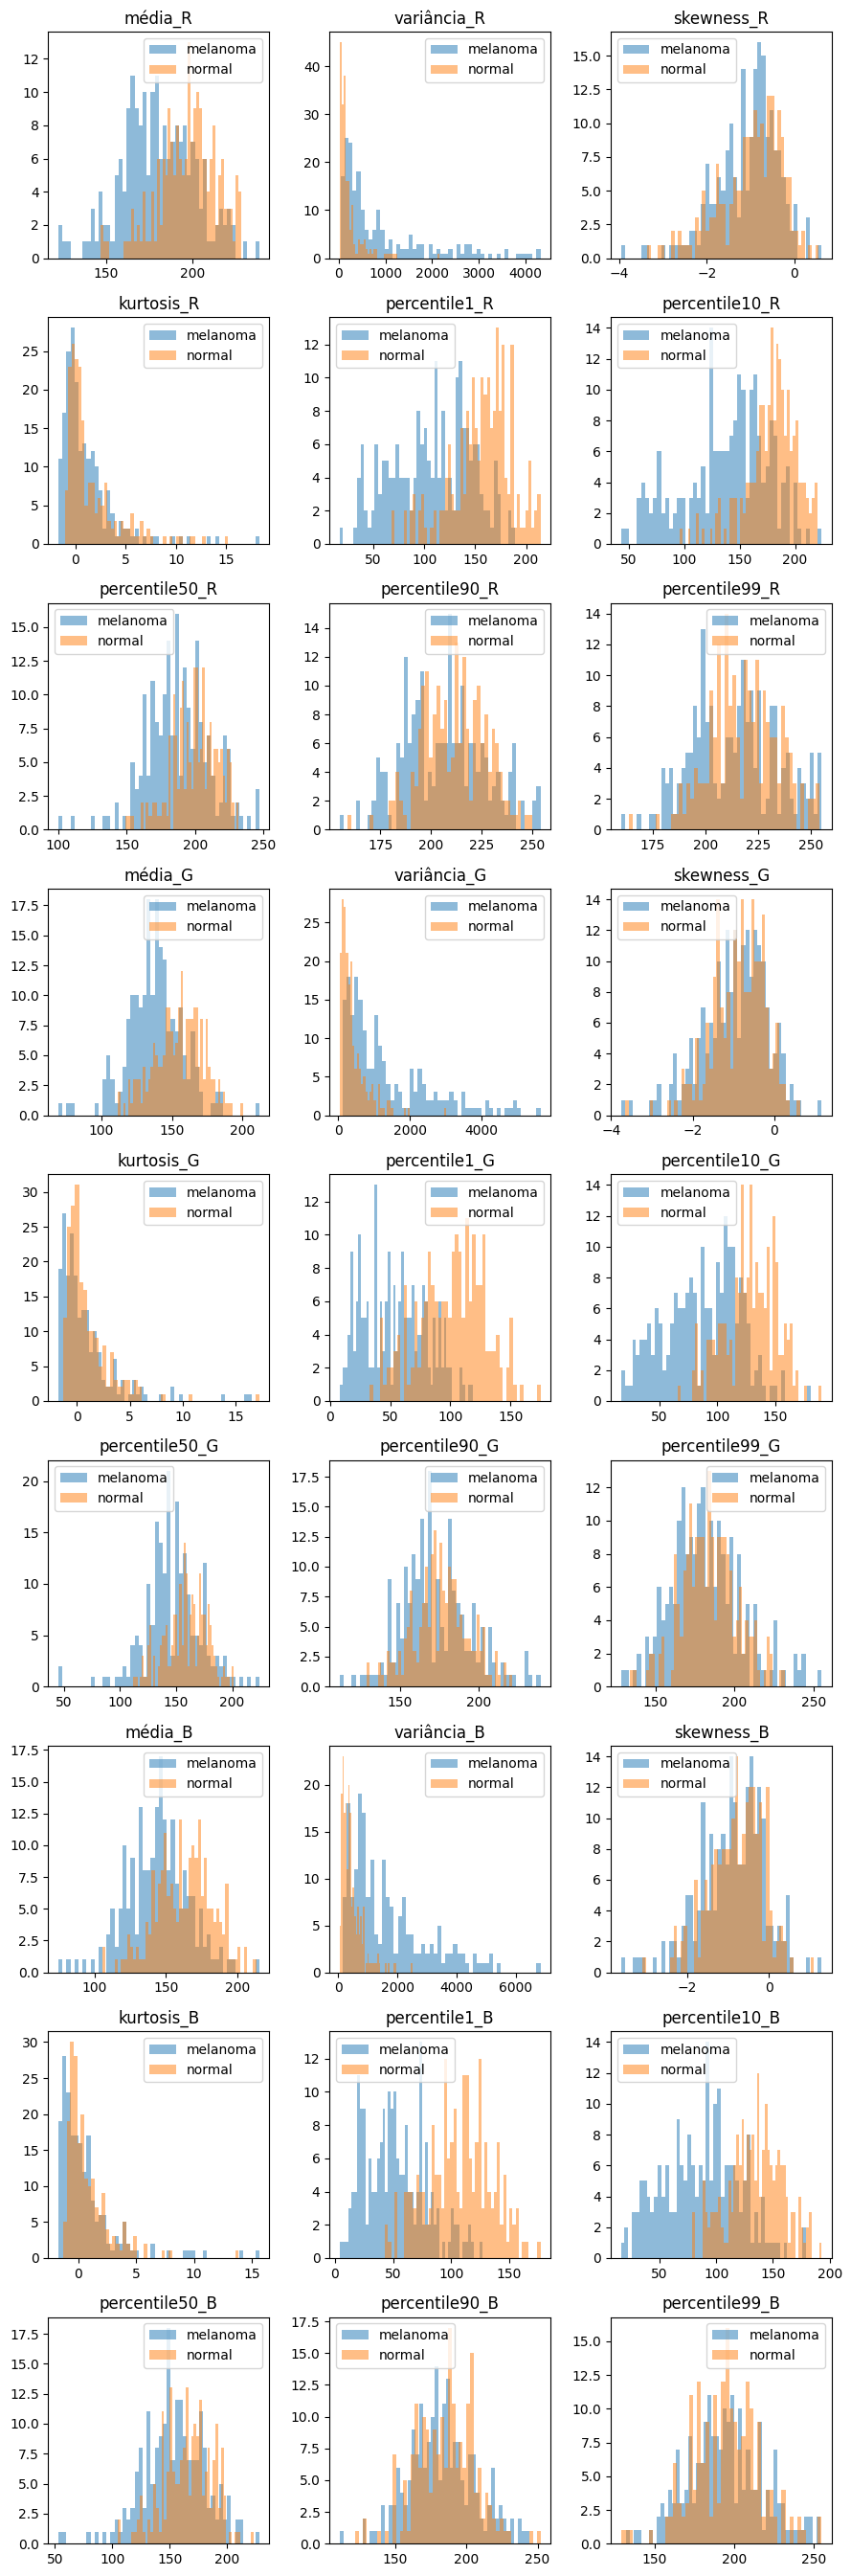

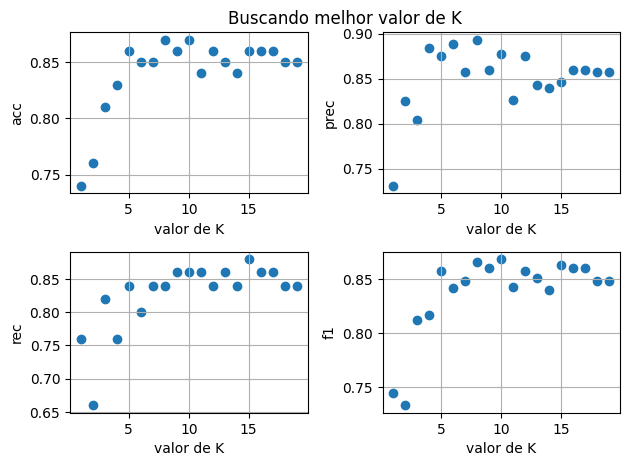

Métricas para k=8
Acurácia: 0.87
Precisão: 0.89
Recall: 0.84
F1-Score: 0.87
Matriz de confusão:
 [[45  5]
 [ 8 42]]


In [ ]:
# A extração de atributos foi realizada concatenando em um único array as métricas extraidas dos histogramas de cada um dos canais da imagem. Utilizar a informação de cor, ausente nas imagens em tons de cinza, ajudou a reduzir o número de falsos positivos apresentados pelo modelo. Com a análise dos histogramas separados pelas categorias, pode-se notar que na banda 'azul', as métricas percentile1, percentile10 e variância possuem uma boa separação das classes.

def FuncaoQueRecebeConjuntoDeImagensRGB3(images): #função que gerará as estatísticas para a imagem redimensionada.
    all_stats = []
    for image in images:
        temp = 0
        image = np.array(Image.fromarray(image).resize((14,14),resample=Image.BILINEAR)) # reduzindo o tamanho da imagem de 28x28x3 para 14x14x3 via interpolação bilinear
        temp = np.concatenate([histstat(image[:,:,0]),histstat(image[:,:,1]),histstat(image[:,:,2])]) # a extração de atributos está sendo feita em cada canal e concatenada em um unico array
        all_stats.append(temp)
    return np.array(all_stats)

stats_train = FuncaoQueRecebeConjuntoDeImagensRGB3(images_train)
print('shape do treino:',stats_train.shape)
stats_test = FuncaoQueRecebeConjuntoDeImagensRGB3(images_test)
print('shape do teste:',stats_test.shape)
#--------------------------------------------------------------------

cores = ['R','G','B']
metricas2 = []
for c in cores:
    for m in metricas:
        metricas2.append(m+'_'+c)
c = 1

plt.clf()
plt.figure(figsize=(9,27))
for idx1, metrica1 in enumerate(metricas2):
    true = stats_train[labels_train==1]
    false = stats_train[labels_train==0]
    plt.subplot(9,3,c)
    plt.title(metrica1)
    plt.hist(true[:,idx1], bins=50,alpha=0.5, label='melanoma') # avaliando a distribuição dos histogramas com base na label
    plt.hist(false[:,idx1],bins=50,alpha=0.5, label='normal') # avaliando a distribuição dos histogramas com base na label
    plt.legend()
    c+=1
plt.tight_layout()
plt.show() # analisando os histogramas, as métricas variancia, percentil1 e percentil10 da banda azul separam bem as duas classes



#REAVALIANDO O VALOR DE K
#--------------------------------------------------------------------
acc,prec,rec,f1 = [],[],[],[]

stats_train_reduzido = stats_train[:, [0, 5, 10, 14, 19, 21]] # seleção de features baseada nos histogramas gerados acima.
stats_test_reduzido = stats_test[:, [0, 5, 10, 14, 19, 21]]

for k in range(1,20): # testando varios valores de K para decidir o melhor.
    model = KNeighborsClassifier(n_neighbors=k)
    
    model.fit(stats_train_reduzido, labels_train); #realiza o treinamento no conjunto de treino
    acc.append(accuracy_score(labels_test, model.predict(stats_test_reduzido))) #calcula as métricas no conjunto de teste
    prec.append(precision_score(labels_test, model.predict(stats_test_reduzido)))
    rec.append(recall_score(labels_test, model.predict(stats_test_reduzido)))
    f1.append(f1_score(labels_test, model.predict(stats_test_reduzido)))

plt.title('Buscando melhor valor de K')
plt.axis('off')
for idx,graph in enumerate([acc,prec,rec,f1]):
    axis = [i for i in range(1,20)]
    plt.subplot(2,2,idx+1)
    plt.scatter(axis,graph)
    plt.xlabel('valor de K')
    plt.ylabel(metric_labels[idx])
    plt.grid()
    plt.tight_layout()
plt.show()

# TREINANDO PARA O MELHOR K (K=8)
model = KNeighborsClassifier(n_neighbors=8) #o melhor K no treino foi 8
model.fit(stats_train_reduzido, labels_train);
# Imprimindo as métricas
print('Métricas para k=8')
print('Acurácia: %.2f' % accuracy_score(labels_test, model.predict(stats_test_reduzido)))
print('Precisão: %.2f' % precision_score(labels_test, model.predict(stats_test_reduzido)))
print('Recall: %.2f' % recall_score(labels_test, model.predict(stats_test_reduzido)))
print('F1-Score: %.2f' % f1_score(labels_test, model.predict(stats_test_reduzido)))

predicts = model.predict(stats_test_reduzido)
matriz_de_confusao = confusion_matrix(labels_test,predicts)
print('Matriz de confusão:\n',matriz_de_confusao)



## Parte 5 - Explorando atributos de textura (opicional para EA979)

Além dos atributos de histograma, existem diversos outros tipos de atributos que podem ser extraídos de imagens digitais, como os atributos de textura, por exemplo. No processamento de imagens, a textura pode ser definida em função da variação espacial da intensidade dos pixels em uma região da imagem. Os atributos de textura são úteis para caracterizar padrões em uma imagem, como rugosidade, suavidade, granulosidade, entre outros. Assim, a análise de textura desempenha um papel importante em casos de visão computacional, como reconhecimento de objetos, detecção de defeitos de superfície, reconhecimento de padrões, análise de imagens médicas, etc.

**Para saber mais sobre atributos de textura, verifique os materiais de apoio disponibilizados no classroom.**

### Exercício 5.1

Extraia atributos de textura (como [GLCM](https://scikit-image.org/docs/stable/auto_examples/features_detection/plot_glcm.html), por exemplo) e repita a classificação. Comente sobre o método de extração de atributos escolhido (como funciona? quais seus parâmetros? que atributos consegue extrair?) e os resultados obtidos.

shape do treino: (400, 4)
shape do teste: (100, 4)


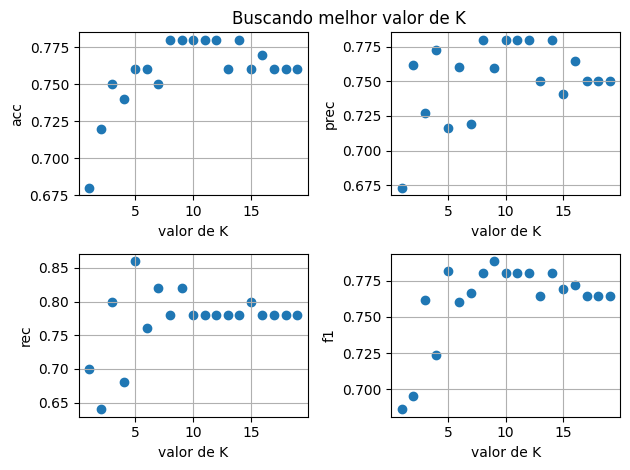

Métricas para k=9
Acurácia: 0.86
Precisão: 0.86
Recall: 0.86
F1-Score: 0.86
Matriz de confusão:
 [[43  7]
 [ 7 43]]


In [ ]:
# Utilizou-se apenas as 4 métricas de textura para treinar o modelo KNN, o desempenho, em quesito da razão FN/TP, foi melhor do que os resultados envolvendo as imagens convertidas para escala de cinza. Comentários sobre o método ao longo do código.


from skimage.feature import graycoprops, graycomatrix
def calcula_GLCM(imagem):
    glcm = graycomatrix(imagem,
                         distances=[1], # número de pixels vizinhos analisados para cada direção
                         angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], #direções a analisar
                         levels=256, # número de intensidades de cinza na imagem
                         )

    contraste = graycoprops(glcm,'contrast')[0,0] # avalia a distância do pixel mais quente para o mais frio
    homogeneidade = graycoprops(glcm, 'homogeneity')[0,0] # avalia o quão igual são os pixels da imagem
    energia = graycoprops(glcm,'energy')[0,0] # soma dos pixels da imagem
    correlação = graycoprops(glcm, 'correlation')[0,0] # avalia o quão pixels vizinhos são iguais
    return np.array([contraste, homogeneidade, energia, correlação])

def FuncaoQueRecebeConjuntoDeImagensRGB4(images): #função que gerará as estatísticas para a imagem redimensionada.
    all_stats = []
    for image in images:
        temp = 0
        image = np.array(Image.fromarray(image).convert('L').resize((14,14),resample=Image.BILINEAR)) # converte a imagem para cinza, reduz o tamanho da imagem de 28x28x3 para 14x14x3 via interpolação bilinear
        all_stats.append(calcula_GLCM(image))
    return np.array(all_stats)

stats_train = FuncaoQueRecebeConjuntoDeImagensRGB4(images_train)
print('shape do treino:',stats_train.shape)
stats_test = FuncaoQueRecebeConjuntoDeImagensRGB4(images_test)
print('shape do teste:',stats_test.shape)


#AVALIANDO O VALOR DE K
#--------------------------------------------------------------------
acc,prec,rec,f1 = [],[],[],[]

for k in range(1,20): # testando varios valores de K para decidir o melhor.
    model = KNeighborsClassifier(n_neighbors=k)
    
    model.fit(stats_train, labels_train); #realiza o treinamento no conjunto de treino
    acc.append(accuracy_score(labels_test, model.predict(stats_test))) #calcula as métricas no conjunto de teste
    prec.append(precision_score(labels_test, model.predict(stats_test)))
    rec.append(recall_score(labels_test, model.predict(stats_test)))
    f1.append(f1_score(labels_test, model.predict(stats_test)))

plt.title('Buscando melhor valor de K')
plt.axis('off')
for idx,graph in enumerate([acc,prec,rec,f1]):
    axis = [i for i in range(1,20)]
    plt.subplot(2,2,idx+1)
    plt.scatter(axis,graph)
    plt.xlabel('valor de K')
    plt.ylabel(metric_labels[idx])
    plt.grid()
    plt.tight_layout()
plt.show()

# TREINANDO PARA O MELHOR K (K=9)
model = KNeighborsClassifier(n_neighbors=9) #o melhor K no treino foi 9
model.fit(stats_train_reduzido, labels_train);
# Imprimindo as métricas
print('Métricas para k=9')
print('Acurácia: %.2f' % accuracy_score(labels_test, model.predict(stats_test_reduzido)))
print('Precisão: %.2f' % precision_score(labels_test, model.predict(stats_test_reduzido)))
print('Recall: %.2f' % recall_score(labels_test, model.predict(stats_test_reduzido)))
print('F1-Score: %.2f' % f1_score(labels_test, model.predict(stats_test_reduzido)))

predicts = model.predict(stats_test_reduzido)
matriz_de_confusao = confusion_matrix(labels_test,predicts)
print('Matriz de confusão:\n',matriz_de_confusao)